In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the Dataset
df = pd.read_csv('insurance.csv')

display(df.head())

# 2. Convert Text to Numbers
# Gradient Descent matrix math requires pure numbers
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# 3. Separate Features (X) and Target (y)
X = df_encoded.drop('charges', axis=1).values # The inputs (Age, BMI, etc.)
y = df_encoded['charges'].values              # The output (Medical Costs)

# 4. Normalize the Features
# This standardizes the data so the math forms a smooth contour.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Add a column of 1s to X for the bias (intercept) term in the matrix calculation
X_scaled = np.c_[np.ones((X_scaled.shape[0], 1)), X_scaled]

# 5. Split the Data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("\n--- Preprocessing Complete! ---")
print(f"Mathematical Matrix Shape for Training: {X_train.shape}")

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



--- Preprocessing Complete! ---
Mathematical Matrix Shape for Training: (1070, 9)


--> Exported 'Hypothesis1_Results_Scaled.xlsx'


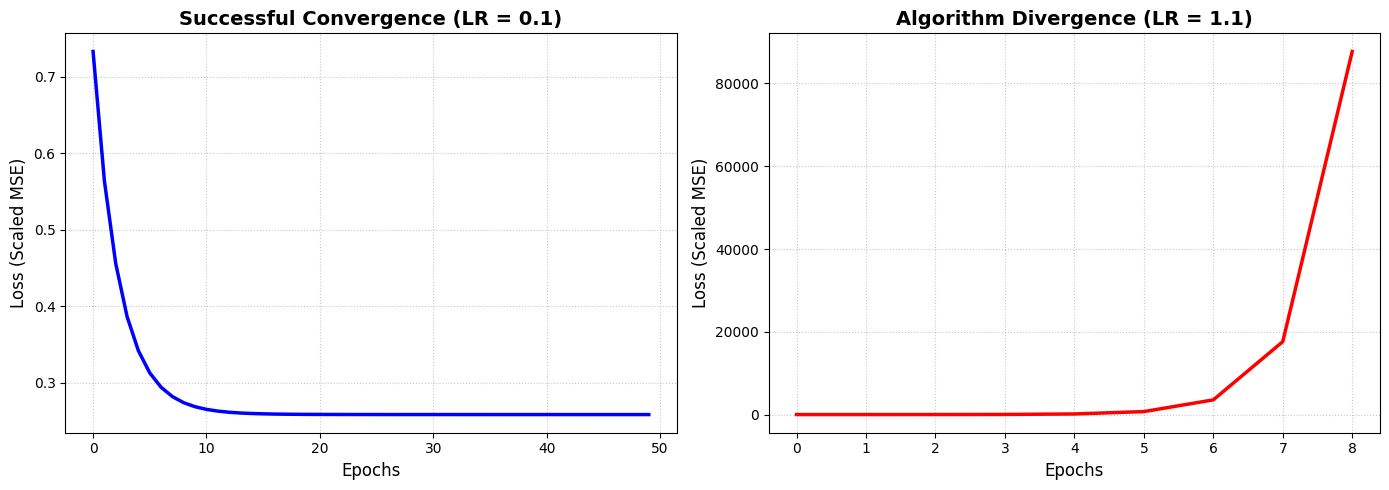

Saved 'Report_Graph_Scaled_Hypothesis1.png' in high-resolution!


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. Normalize the Target (y)
# ==========================================
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()

# ==========================================
# 2. Batch Gradient Descent Algorithm
# ==========================================
def batch_gradient_descent(X, y, learning_rate, epochs):
    m = len(y)
    weights = np.zeros(X.shape[1])
    loss_history = []
    
    for epoch in range(epochs):
        error = X.dot(weights) - y
        gradients = (2/m) * X.T.dot(error)
        weights -= learning_rate * gradients
        loss = np.mean((X.dot(weights) - y)**2)
        
        # Safety catch to prevent the line from stretching to infinity visually
        if np.isinf(loss) or np.isnan(loss) or loss > 1e5:
            loss_history.append(np.nan)
        else:
            loss_history.append(loss)
            
    return loss_history

# ==========================================
# 3. Test Question 1 / Hypothesis 1 
#    (Convergence vs Divergence)
# ==========================================
epochs = 50

# A "Good" Learning Rate will smoothly converge to ~0.26
loss_converge = batch_gradient_descent(X_train, y_train_scaled, learning_rate=0.1, epochs=epochs)

# A "Bad" (Too High) Learning Rate will bounce wildly and diverge!
loss_diverge = batch_gradient_descent(X_train, y_train_scaled, learning_rate=1.1, epochs=epochs)

# ==========================================
# 4. Save metrics to Excel
# ==========================================
metrics_q1 = pd.DataFrame({
    'Epoch': range(1, epochs + 1),
    'Converging_Loss_LR_0.1': loss_converge,
    'Diverging_Loss_LR_1.1': loss_diverge
})
metrics_q1.to_excel('Hypothesis1_Results_Scaled.xlsx', index=False)
print("--> Exported 'Hypothesis1_Results_Scaled.xlsx'")

# ==========================================
# 5. Plot the Clean Results for the Report
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Convergence Plot
ax1.plot(range(epochs), loss_converge, color='blue', linewidth=2.5)
ax1.set_title('Successful Convergence (LR = 0.1)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss (Scaled MSE)', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.7)

# Divergence Plot
ax2.plot(range(epochs), loss_diverge, color='red', linewidth=2.5)
ax2.set_title('Algorithm Divergence (LR = 1.1)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Loss (Scaled MSE)', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.savefig('Report_Graph_Scaled_Hypothesis1.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved 'Report_Graph_Scaled_Hypothesis1.png' in high-resolution!")

Running Batch GD vs. Adam Optimizer...

FINAL SCALED MSE & COMPUTATIONAL EFFICIENCY
Batch GD Final MSE : 0.2583  |  Time: 0.010530 seconds
Adam Optimizer MSE : 0.2630  |  Time: 0.004253 seconds


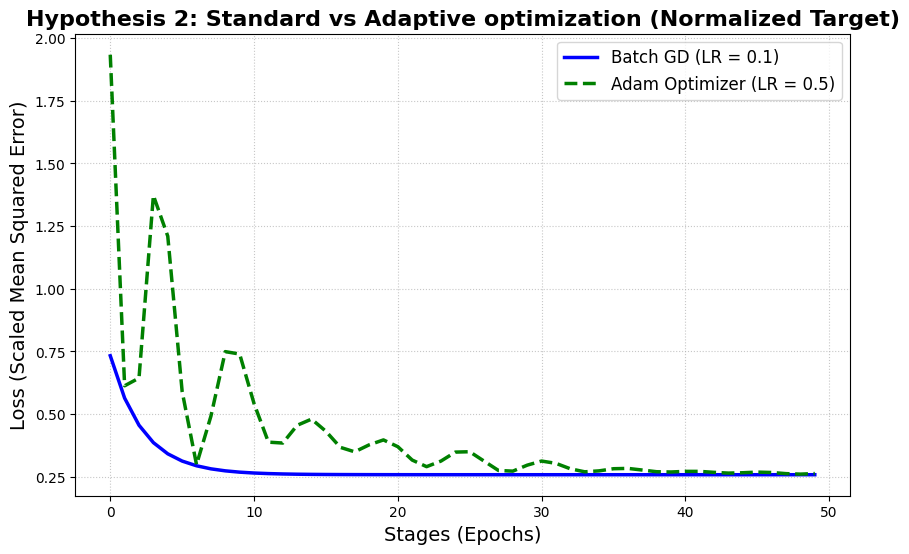

In [11]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. Normalize the Target (y)
# ==========================================
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()

# ==========================================
# 2. The Algorithms (With Timers)
# ==========================================
def batch_gradient_descent_timed(X, y, learning_rate, epochs):
    m = len(y)
    weights = np.zeros(X.shape[1])
    loss_history = []
    start_time = time.time()
    for epoch in range(epochs):
        error = X.dot(weights) - y
        gradients = (2/m) * X.T.dot(error)
        weights -= learning_rate * gradients
        loss_history.append(np.mean((X.dot(weights) - y)**2))
    return loss_history, time.time() - start_time

def adam_optimizer_timed(X, y, learning_rate, epochs):
    m = len(y)
    weights = np.zeros(X.shape[1])
    loss_history = []
    beta1, beta2, epsilon = 0.9, 0.999, 1e-8
    m_t, v_t = np.zeros(X.shape[1]), np.zeros(X.shape[1])
    
    start_time = time.time()
    for epoch in range(1, epochs + 1):
        error = X.dot(weights) - y
        gradients = (2/m) * X.T.dot(error)
        
        # Adam's "Heavy" Math
        m_t = beta1 * m_t + (1 - beta1) * gradients
        v_t = beta2 * v_t + (1 - beta2) * (gradients**2)
        m_t_hat = m_t / (1 - beta1**epoch)
        v_t_hat = v_t / (1 - beta2**epoch)
        weights -= learning_rate * m_t_hat / (np.sqrt(v_t_hat) + epsilon)
        
        loss_history.append(np.mean((X.dot(weights) - y)**2))
    return loss_history, time.time() - start_time

# ==========================================
# 3. Run the Race!
# ==========================================
epochs = 50

print("Running Batch GD vs. Adam Optimizer...")
loss_batch, time_batch = batch_gradient_descent_timed(X_train, y_train_scaled, learning_rate=0.1, epochs=epochs)
loss_adam, time_adam = adam_optimizer_timed(X_train, y_train_scaled, learning_rate=0.5, epochs=epochs)

# ==========================================
# 4. Print the Scoreboard for the Report
# ==========================================
print("\n" + "="*50)
print("FINAL SCALED MSE & COMPUTATIONAL EFFICIENCY")
print("="*50)
print(f"Batch GD Final MSE : {loss_batch[-1]:.4f}  |  Time: {time_batch:.6f} seconds")
print(f"Adam Optimizer MSE : {loss_adam[-1]:.4f}  |  Time: {time_adam:.6f} seconds")
print("="*50)

# ==========================================
# 5. Plot the Final Comparison
# ==========================================
plt.figure(figsize=(10, 6))

plt.plot(range(epochs), loss_batch, label='Batch GD (LR = 0.1)', color='blue', linewidth=2.5)
plt.plot(range(epochs), loss_adam, label='Adam Optimizer (LR = 0.5)', color='green', linewidth=2.5, linestyle='--')

plt.title('Hypothesis 2: Standard vs Adaptive optimization (Normalized Target)', fontsize=16, fontweight='bold')
plt.xlabel('Stages (Epochs)', fontsize=14)
plt.ylabel('Loss (Scaled Mean Squared Error)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

# Save directly for the Word Document
plt.savefig('Report_Graph_Scaled_Batch_vs_Adam.png', dpi=300, bbox_inches='tight')
plt.show()

Running Batch GD (Full matrix calculations)...
Running Stochastic GD (Row-by-row updates)...

FINAL SCALED MSE & COMPUTATIONAL EFFICIENCY
Batch GD Final MSE : 0.2583  |  Time: 0.0022 seconds
Stochastic GD MSE  : 0.2859  |  Time: 0.7816 seconds


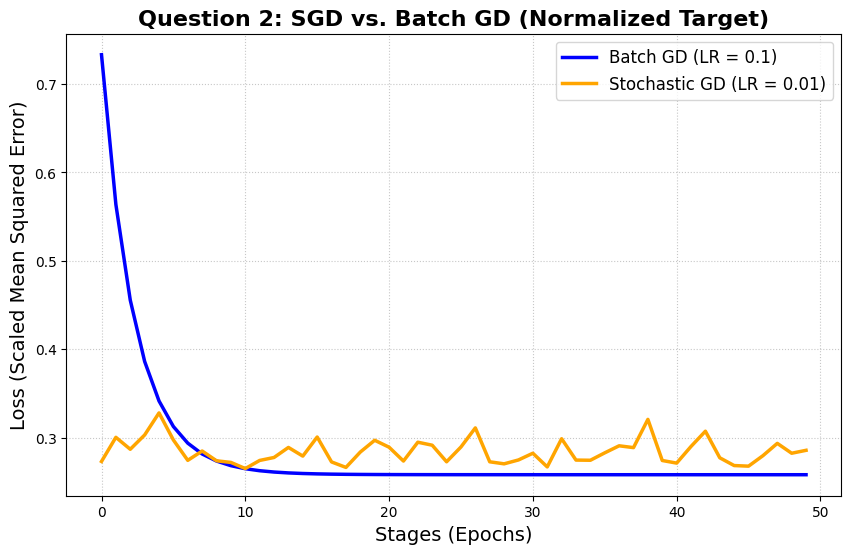


Saved 'Report_Graph_Scaled_SGD_vs_Batch.png' in high-resolution!


In [7]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. Normalize the Target (y)
# ==========================================
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()

# ==========================================
# 2. The Algorithms
# ==========================================
def batch_gradient_descent_timed(X, y, learning_rate, epochs):
    m = len(y)
    weights = np.zeros(X.shape[1])
    loss_history = []
    start_time = time.time()
    for epoch in range(epochs):
        error = X.dot(weights) - y
        gradients = (2/m) * X.T.dot(error)
        weights -= learning_rate * gradients
        loss_history.append(np.mean((X.dot(weights) - y)**2))
    return loss_history, time.time() - start_time

def stochastic_gradient_descent(X, y, learning_rate, epochs):
    m = len(y)
    weights = np.zeros(X.shape[1])
    loss_history = []
    start_time = time.time()
    for epoch in range(epochs):
        # SGD updates weights row-by-row
        for i in range(m):
            random_index = np.random.randint(m)
            Xi = X[random_index:random_index+1]
            yi = y[random_index:random_index+1]
            
            error = Xi.dot(weights) - yi
            gradients = 2 * Xi.T.dot(error)
            weights -= learning_rate * gradients
            
        loss_history.append(np.mean((X.dot(weights) - y)**2))
    return loss_history, time.time() - start_time

# ==========================================
# 3. Run the Race!
# ==========================================
epochs = 50

print("Running Batch GD (Full matrix calculations)...")
loss_batch, time_batch = batch_gradient_descent_timed(X_train, y_train_scaled, learning_rate=0.1, epochs=epochs)

print("Running Stochastic GD (Row-by-row updates)...")
# SGD uses a smaller learning rate to prevent wild bouncing
loss_sgd, time_sgd = stochastic_gradient_descent(X_train, y_train_scaled, learning_rate=0.01, epochs=epochs)

# ==========================================
# 4. Print the Scoreboard for the Report
# ==========================================
print("\n" + "="*50)
print("FINAL SCALED MSE & COMPUTATIONAL EFFICIENCY")
print("="*50)
print(f"Batch GD Final MSE : {loss_batch[-1]:.4f}  |  Time: {time_batch:.4f} seconds")
print(f"Stochastic GD MSE  : {loss_sgd[-1]:.4f}  |  Time: {time_sgd:.4f} seconds")
print("="*50)

# ==========================================
# 5. Plot the Final Report Graph
# ==========================================
plt.figure(figsize=(10, 6))

plt.plot(range(epochs), loss_batch, label='Batch GD (LR = 0.1)', color='blue', linewidth=2.5)
plt.plot(range(epochs), loss_sgd, label='Stochastic GD (LR = 0.01)', color='orange', linewidth=2.5)

plt.title('Question 2: SGD vs. Batch GD (Normalized Target)', fontsize=16, fontweight='bold')
plt.xlabel('Stages (Epochs)', fontsize=14)
plt.ylabel('Loss (Scaled Mean Squared Error)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

# Save directly for the Word Document
plt.savefig('Report_Graph_Scaled_SGD_vs_Batch.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved 'Report_Graph_Scaled_SGD_vs_Batch.png' in high-resolution!")

In [12]:
import time
import numpy as np

# ==========================================
# 1. The Matrix (Vectorized) Approach
# ==========================================
def vectorized_gd(X, y, learning_rate, epochs):
    m = len(y)
    weights = np.zeros(X.shape[1])
    start_time = time.time()
    
    for epoch in range(epochs):
        error = X.dot(weights) - y
        
        # ONE mathematical step updates all 8 features simultaneously 
        gradients = (2/m) * X.T.dot(error) 
        weights -= learning_rate * gradients
        
    return time.time() - start_time

# ==========================================
# 2. The Slow "For-Loop" Approach
# ==========================================
def non_vectorized_gd(X, y, learning_rate, epochs):
    m = len(y)
    n_features = X.shape[1] # We have 8 features + 1 bias
    weights = np.zeros(n_features)
    start_time = time.time()
    
    for epoch in range(epochs):
        error = X.dot(weights) - y
        gradients = np.zeros(n_features)
        
        # SLOW: We force Python to calculate the gradient for Age, then BMI, then Smoker...
        for j in range(n_features):
            gradients[j] = (2/m) * np.sum(error * X[:, j])
            
        weights -= learning_rate * gradients
        
    return time.time() - start_time

# ==========================================
# 3. Run the Question 3 Proof (Consistent 50 Epochs)
# ==========================================
epochs = 50

print("Running Matrix Vectorization Proof (Question 3)...\n")

time_matrix = vectorized_gd(X_train, y_train_scaled, 0.1, epochs)
time_loops = non_vectorized_gd(X_train, y_train_scaled, 0.1, epochs)

print("="*50)
print(f"COMPUTATIONAL TIME ({epochs} Epochs)")
print("="*50)
print(f"Matrix (Vectorized) Time : {time_matrix:.6f} seconds")
print(f"For-Loop (Iterative) Time: {time_loops:.6f} seconds")
print("="*50)

speedup = time_loops / time_matrix
print(f"\nCONCLUSION: The Matrix approach is {speedup:.1f}x FASTER than the loop approach!")

Running Matrix Vectorization Proof (Question 3)...

COMPUTATIONAL TIME (50 Epochs)
Matrix (Vectorized) Time : 0.011722 seconds
For-Loop (Iterative) Time: 0.022247 seconds

CONCLUSION: The Matrix approach is 1.9x FASTER than the loop approach!
